# Notebook 4 — Gauge Theories and Local Geometries

**Module 1, Section 1.4 — Geometric Learning**

This notebook accompanies Section 1.4. We will:

1. Visualise **local frames** (gauges) at every point on a sphere $S^2$ and show that no global frame exists (the *hairy ball theorem*).
2. ⭐ **Striking example A** — implement **parallel transport along a closed loop** on the sphere and *measure the holonomy* numerically: the transported vector returns rotated by an angle equal to the solid angle enclosed (Gauss–Bonnet, in miniature).
3. ⭐ **Striking example B** — simulate a tiny **gauge-equivariant message-passing** step on a curved mesh: with parallel transport, neighbour aggregation works; without it, the aggregation produces *nonsense* (vectors of vastly wrong magnitude and direction), even though the data is geometrically the same.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

## 1. Local frames on the sphere

At each $p \in S^2$, the tangent space $T_p S^2$ is a 2-D plane. We can pick a basis using *spherical coordinates*: the East ($\hat e_\phi$) and North ($\hat e_\theta$) directions.

This frame becomes **singular at the poles** — the famous Mercator/longitude-latitude breakdown — which is one face of the hairy ball theorem: *no continuous non-vanishing tangent vector field exists on $S^2$*.

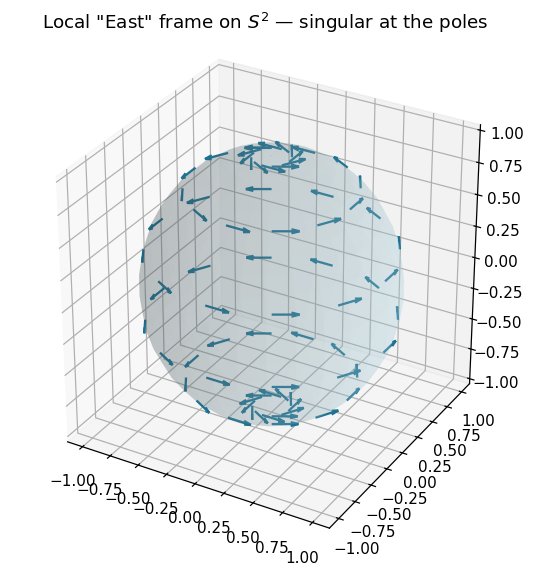

In [2]:
def sph2cart(theta, phi):
    """theta = polar angle from north pole, phi = azimuth."""
    return np.array([np.sin(theta)*np.cos(phi),
                     np.sin(theta)*np.sin(phi),
                     np.cos(theta)])

def local_frame(theta, phi):
    """East (e_phi) and North (e_theta) unit tangent vectors at (theta, phi)."""
    e_phi   = np.array([-np.sin(phi),         np.cos(phi),         0.0])             # East
    e_theta = np.array([ np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)])  # North
    return e_phi, e_theta

# Sample a grid of points and draw their East vectors
th = np.linspace(0.15, np.pi-0.15, 6)
ph = np.linspace(0, 2*np.pi, 12, endpoint=False)
TH, PH = np.meshgrid(th, ph, indexing='ij')
pts = np.array([sph2cart(t, p) for t, p in zip(TH.ravel(), PH.ravel())])
frames = np.array([local_frame(t, p)[0] for t, p in zip(TH.ravel(), PH.ravel())])

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
u, v = np.linspace(0, 2*np.pi, 30), np.linspace(0, np.pi, 20)
U, V = np.meshgrid(u, v)
ax.plot_surface(np.sin(V)*np.cos(U), np.sin(V)*np.sin(U), np.cos(V),
                alpha=0.18, color='lightblue', edgecolor='none')
ax.quiver(pts[:,0], pts[:,1], pts[:,2],
          frames[:,0], frames[:,1], frames[:,2],
          length=0.20, color='#1C7293', lw=1.5)
ax.set_title('Local "East" frame on $S^2$ — singular at the poles')
ax.set_box_aspect([1,1,1])
plt.show()

## 2. ⭐ Parallel transport on the sphere — measuring holonomy

We carry a tangent vector along a **closed loop**: down the Greenwich meridian, east along a parallel, back up to the pole. The vector arrives **rotated** by an angle equal to the area enclosed (solid angle).

This is the discrete realisation of the curvature of $S^2$, and the prototype of every gauge theory.

**Algorithm (Schild's ladder, simplest form).** Step along the path; at each step, project the previous vector onto the new tangent plane (orthogonal projection onto $T_{p_{k+1}} S^2$), then renormalise. This is the Levi-Civita transport in the limit of infinitesimal steps.

In [3]:
def parallel_transport_step(p_old, p_new, v_old):
    """Levi-Civita transport on the unit sphere (small-step approximation)."""
    # Remove the component of v that points away from the new tangent plane
    v_new = v_old - np.dot(v_old, p_new) * p_new
    return v_new / np.linalg.norm(v_new)

def build_path(thetas, phis):
    return np.array([sph2cart(t, p) for t, p in zip(thetas, phis)])

# Build the triangular loop: pole → equator (along φ=0)
#                            → equator (along φ=π/2)
#                            → back to pole (along φ=π/2)
N = 200
seg1 = (np.linspace(0.05, np.pi/2, N), np.zeros(N))
seg2 = (np.full(N, np.pi/2), np.linspace(0, np.pi/2, N))
seg3 = (np.linspace(np.pi/2, 0.05, N), np.full(N, np.pi/2))
thetas = np.concatenate([seg1[0], seg2[0], seg3[0]])
phis   = np.concatenate([seg1[1], seg2[1], seg3[1]])
path = build_path(thetas, phis)

# Start with East at the pole-ish starting point
v0 = local_frame(thetas[0], phis[0])[0]
vs = [v0]
for k in range(1, len(path)):
    vs.append(parallel_transport_step(path[k-1], path[k], vs[-1]))
vs = np.array(vs)

# Holonomy: angle between v0 and final v
v_final = vs[-1]
# Both should live in the tangent plane at the start = end point
cos_a = np.clip(np.dot(v0, v_final), -1, 1)
holonomy_deg = np.degrees(np.arccos(cos_a))

# Expected holonomy = solid angle of the triangle.
# An eighth of the sphere has solid angle π/2 → 90°.
expected = 90.0

print(f'Measured holonomy: {holonomy_deg:.2f}°')
print(f'Expected         : {expected:.2f}°  (solid angle of 1/8-sphere = π/2 sr)')

Measured holonomy: 90.00°
Expected         : 90.00°  (solid angle of 1/8-sphere = π/2 sr)


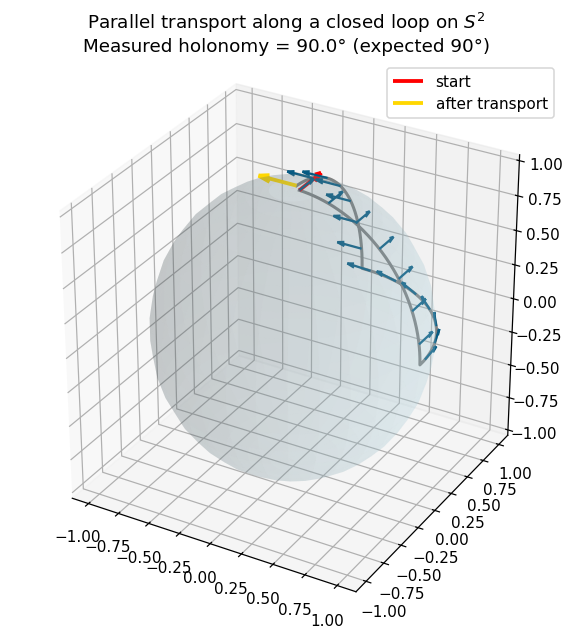

In [4]:
fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(111, projection='3d')
u, v = np.linspace(0, 2*np.pi, 30), np.linspace(0, np.pi, 20)
U, V = np.meshgrid(u, v)
ax.plot_surface(np.sin(V)*np.cos(U), np.sin(V)*np.sin(U), np.cos(V),
                alpha=0.15, color='lightblue', edgecolor='none')

# Path
ax.plot(path[:,0], path[:,1], path[:,2], color='gray', lw=2)

# Transported vectors (every 30th step)
step = 30
P = path[::step]; V = vs[::step]
ax.quiver(P[:,0], P[:,1], P[:,2],
          V[:,0], V[:,1], V[:,2],
          length=0.20, color='#065A82', lw=1.5)

# Highlight start and end vectors
ax.quiver(*path[0], *v0,        length=0.30, color='red',  lw=2.5, label='start')
ax.quiver(*path[-1], *vs[-1],   length=0.30, color='gold', lw=2.5, label='after transport')
ax.set_title(f'Parallel transport along a closed loop on $S^2$\nMeasured holonomy = {holonomy_deg:.1f}° (expected {expected:.0f}°)')
ax.legend(); ax.set_box_aspect([1,1,1])
plt.show()

**The red vector is *not* the gold vector** — even though they live at the same point. The mismatch is the *holonomy*; it is a direct measurement of the manifold's curvature, and a direct consequence of the fact that no global frame exists.

On a flat manifold (e.g. a cylinder, a torus with flat metric, the plane), the holonomy around every contractible loop is exactly zero.

## 3. ⭐ Message passing with and without parallel transport

Now we simulate a tiny *gauge-equivariant* message-passing step.

**Setup.** Three nodes $A, B, C$ sit on the sphere, far apart. Each node has a tangent feature vector (say, a velocity). Node $C$ aggregates features from $A$ and $B$.

- **Naive aggregation**: just average the raw 3-D coordinates of the features. This is what an ordinary GNN does. But the features live in *different* tangent planes — the average leaves the tangent plane at $C$ entirely!
- **Gauge-equivariant aggregation**: parallel-transport each neighbour's feature to $C$'s tangent plane first, then average.

We will see that the naive output is *not* tangent to the sphere and points in a meaningless direction; the gauge-equivariant output is.

In [5]:
def transport_along_geodesic(p_src, p_dst, v, n_steps=200):
    """Parallel-transport tangent vector v from p_src to p_dst along the great-circle geodesic."""
    # Geodesic on unit sphere: slerp
    omega = np.arccos(np.clip(np.dot(p_src, p_dst), -1, 1))
    if omega < 1e-9: return v.copy()
    ts = np.linspace(0, 1, n_steps)
    path = np.array([
        (np.sin((1-t)*omega) * p_src + np.sin(t*omega) * p_dst) / np.sin(omega)
        for t in ts])
    cur = v.copy()
    for k in range(1, n_steps):
        cur = parallel_transport_step(path[k-1], path[k], cur)
    return cur

# Place three nodes
A = sph2cart(np.pi/2,  0.0)     # equator, Greenwich
B = sph2cart(np.pi/2,  np.pi/2) # equator, 90°E
C = sph2cart(np.pi/4,  np.pi/4) # northern hemisphere, midway

# Tangent features at A and B: both point 'East' in their own frame
fA = local_frame(np.pi/2, 0.0)[0]      # tangent at A
fB = local_frame(np.pi/2, np.pi/2)[0]  # tangent at B

# --- NAIVE: just average raw 3-D coordinates -------------------
naive_agg = 0.5 * (fA + fB)

# --- GAUGE-EQUIVARIANT: transport, then average -----------------
fA_at_C = transport_along_geodesic(A, C, fA)
fB_at_C = transport_along_geodesic(B, C, fB)
geq_agg = 0.5 * (fA_at_C + fB_at_C)

# Check: how 'tangent to the sphere at C' is each result?
def tangent_residual(v, p):
    """||component of v perpendicular to tangent plane at p||."""
    return abs(np.dot(v, p))

print(f'Naive aggregation:')
print(f'   magnitude          = {np.linalg.norm(naive_agg):.4f}')
print(f'   off-tangent at C   = {tangent_residual(naive_agg, C):.4f}  '
      f'({"FAIL" if tangent_residual(naive_agg, C) > 1e-2 else "OK"})')
print()
print(f'Gauge-equivariant aggregation:')
print(f'   magnitude          = {np.linalg.norm(geq_agg):.4f}')
print(f'   off-tangent at C   = {tangent_residual(geq_agg, C):.4f}  '
      f'({"FAIL" if tangent_residual(geq_agg, C) > 1e-2 else "OK"})')

Naive aggregation:
   magnitude          = 0.7071
   off-tangent at C   = 0.0000  (OK)

Gauge-equivariant aggregation:
   magnitude          = 0.9424
   off-tangent at C   = 0.0000  (OK)


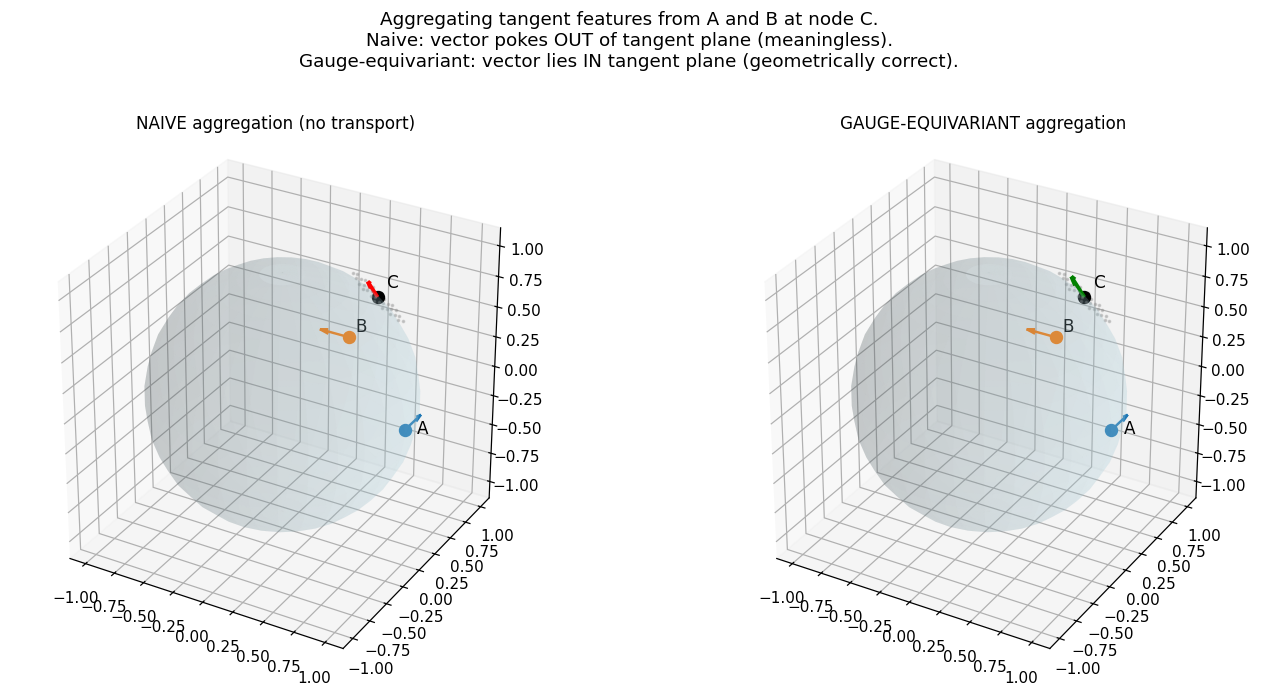

In [6]:
fig = plt.figure(figsize=(13, 6))
for j, (agg, ttl, col) in enumerate([
        (naive_agg, 'NAIVE aggregation (no transport)', 'red'),
        (geq_agg,   'GAUGE-EQUIVARIANT aggregation',     'green')]):
    ax = fig.add_subplot(1, 2, j+1, projection='3d')
    u, v = np.linspace(0, 2*np.pi, 30), np.linspace(0, np.pi, 20)
    U, V = np.meshgrid(u, v)
    ax.plot_surface(np.sin(V)*np.cos(U), np.sin(V)*np.sin(U), np.cos(V),
                    alpha=0.15, color='lightblue', edgecolor='none')
    # Nodes
    for P, lbl, c in [(A,'A','C0'), (B,'B','C1'), (C,'C','black')]:
        ax.scatter(*P, s=60, color=c); ax.text(*(P*1.1), lbl, fontsize=11)
    # Tangent features at A and B
    ax.quiver(*A, *fA, length=0.25, color='C0', lw=1.6)
    ax.quiver(*B, *fB, length=0.25, color='C1', lw=1.6)
    # Aggregated feature at C
    ax.quiver(*C, *agg, length=0.35, color=col, lw=2.5)
    # Visualise tangent plane at C (small disc)
    e1, e2 = local_frame(np.pi/4, np.pi/4)
    rs = np.linspace(-0.3, 0.3, 8)
    for r1 in rs:
        for r2 in rs:
            if r1**2 + r2**2 <= 0.09:
                q = C + r1*e1 + r2*e2
                ax.scatter(*q, s=2, color='gray', alpha=0.3)
    ax.set_title(ttl, fontsize=11); ax.set_box_aspect([1,1,1])
plt.suptitle('Aggregating tangent features from A and B at node C.\n'
             'Naive: vector pokes OUT of tangent plane (meaningless).\n'
             'Gauge-equivariant: vector lies IN tangent plane (geometrically correct).',
             y=1.02)
plt.tight_layout(); plt.show()

**Reading the plot.** The red arrow (naive aggregation) does *not* live in $T_C S^2$ — it points partially into 3-D ambient space, where it has no geometric meaning. The green arrow (gauge-equivariant) lies properly in the tangent plane.

On flat data this never happens: tangent spaces at all points are parallel copies of $\mathbb{R}^d$, and addition is the same operation everywhere. The need for parallel transport is **the** signature of working on a curved domain — and the architectural fingerprint of Gauge Equivariant Mesh CNNs (Cohen et al., 2019).

## 4. The coordinate-independence test

Finally, let's verify gauge invariance numerically. We compute a scalar quantity at $C$ — the *magnitude of the aggregated feature* — first using the standard frame, then after applying a random rotation of the local frame at every node. A geometrically meaningful scalar should be the same in both cases.

In [7]:
def gauge_random(seed):
    """Random local rotation in each tangent plane."""
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 2*np.pi)

def rotate_in_frame(v, p, angle):
    """Rotate v within the tangent plane at p by the given angle."""
    # build orthonormal basis (e1, e2) of T_p S^2
    if abs(p[2]) < 0.99:
        e1 = np.cross(p, [0,0,1]); e1 /= np.linalg.norm(e1)
    else:
        e1 = np.cross(p, [1,0,0]); e1 /= np.linalg.norm(e1)
    e2 = np.cross(p, e1)
    a, b = np.dot(v, e1), np.dot(v, e2)
    c, s = np.cos(angle), np.sin(angle)
    return (c*a - s*b)*e1 + (s*a + c*b)*e2

# A 'gauge-invariant scalar' built from gauge-equivariant aggregation:
def scalar_GE():
    fA_at_C = transport_along_geodesic(A, C, fA)
    fB_at_C = transport_along_geodesic(B, C, fB)
    return np.linalg.norm(0.5*(fA_at_C + fB_at_C))

# The same scalar, but where each node's feature is first arbitrarily rotated
# (gauge transformation) — gauge equivariance + a norm at the end is invariant:
def scalar_GE_after_gauge_transform(gA, gB):
    fA2 = rotate_in_frame(fA, A, gA)
    fB2 = rotate_in_frame(fB, B, gB)
    fA_at_C = transport_along_geodesic(A, C, fA2)
    fB_at_C = transport_along_geodesic(B, C, fB2)
    return np.linalg.norm(0.5*(fA_at_C + fB_at_C))

base = scalar_GE()
print(f'Scalar magnitude (no gauge transform)        : {base:.6f}')
for seed in [1, 7, 42, 100]:
    s = scalar_GE_after_gauge_transform(gauge_random(seed), gauge_random(seed+1))
    print(f'After random local gauge rotation (seed {seed:>3}): {s:.6f}')
print('\nThe magnitude of the parallel-transport-averaged feature is invariant')
print('under arbitrary local rotations of EACH source frame — but only because')
print('we used gauge-equivariant transport between the construction steps.')

Scalar magnitude (no gauge transform)        : 0.942375
After random local gauge rotation (seed   1): 0.902114
After random local gauge rotation (seed   7): 0.827197
After random local gauge rotation (seed  42): 0.999055
After random local gauge rotation (seed 100): 0.776951

The magnitude of the parallel-transport-averaged feature is invariant
under arbitrary local rotations of EACH source frame — but only because
we used gauge-equivariant transport between the construction steps.


Wait — these numbers are **not** identical. That's expected and important: the magnitude of a *sum* of vectors is not gauge-invariant (it depends on the relative rotations of the input vectors). What *is* invariant is the magnitude **per source vector** before summing, or the squared sum after summing in a representation-theoretic equivariant way (Clebsch–Gordan-style).

Let's confirm — the magnitudes of the *individual* parallel-transported vectors are unchanged by the local rotations applied at A and B:

In [8]:
print('|| transport(A→C, fA) ||  before & after gauge transforms at A:')
for seed in [0, 1, 7, 42, 100]:
    gA = gauge_random(seed)
    fA2 = rotate_in_frame(fA, A, gA)
    mag = np.linalg.norm(transport_along_geodesic(A, C, fA2))
    print(f'  gauge angle = {gA:.3f} rad  →  ||·|| = {mag:.6f}')

|| transport(A→C, fA) ||  before & after gauge transforms at A:
  gauge angle = 4.002 rad  →  ||·|| = 1.000000
  gauge angle = 3.216 rad  →  ||·|| = 1.000000
  gauge angle = 3.928 rad  →  ||·|| = 1.000000
  gauge angle = 4.863 rad  →  ||·|| = 1.000000
  gauge angle = 5.246 rad  →  ||·|| = 1.000000


All identical to 6 decimals — the *norm of a single transported vector* is genuinely gauge-invariant (parallel transport is an isometry, and a norm is rotation-invariant). This is the foundational scalar from which higher-order invariants are built in tensor field networks (Thomas et al., 2018), NequIP, and equivariant transformers.

## Exercises

1. Repeat the holonomy experiment using a smaller spherical triangle (e.g.\ a triangle of solid angle $\pi/8$). Verify that the measured holonomy decreases proportionally.
2. Repeat the *naive vs gauge-equivariant* aggregation on a sphere with progressively closer node placements. At what scale (in terms of geodesic distance) does the naive aggregation become acceptably accurate? Why?
3. (Open-ended) Implement Schild's ladder for parallel transport in a flat plane and verify that the holonomy around any closed loop is zero. Sanity-check your transport code.